# Gray-Scott reaction-diffusion — dataset overview

Presentation figures for **The Well**'s `gray_scott_reaction_diffusion` track
([Ohana et al. 2024](https://arxiv.org/abs/2412.00568)).

Each simulation is a 2D physical *video* of two chemical fields **A** and **B**
diffusing and reacting on a 128×128 grid. A trajectory has **1001 timesteps**;
the feed/kill parameters `(F, k)` define visually distinct regimes (spots,
worms, maze-like, ...), one regime per HDF5 file. A training clip is
`[2, T, 128, 128]`, z-scored per channel.

This notebook builds the figures that introduce the data:

1. Field snapshots — A vs B
2. Temporal montage of one trajectory
3. Regime gallery
4. Value distributions vs the z-score statistics
5. Radial power spectrum (characteristic length scales)
6. Temporal change-rate (motivates `time_stride`)
7. Animated trajectory (GIF)

All figures are saved to `figures/out/` as PNG + SVG.

**Data source** is automatic: local HDF5 → the_well HF streaming → a built-in
synthetic Gray-Scott solver, so this runs even with no data staged.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import plot_style as ps

ps.setup_style()

# --- configuration -------------------------------------------------------- #
# Point DATA_ROOT at a folder containing data/<split>/*.hdf5 (the layout of
# eb_jepa/datasets/gray_scott/dataset.py). Leave "" to stream from HF / use the
# synthetic fallback.
DATA_ROOT = ""            # e.g. "/lustre/.../gray_scott_reaction_diffusion"
SPLIT = "train"
N_FRAMES = 16             # frames in the demo clip
TIME_STRIDE = 4           # spacing between frames (Gray-Scott evolves slowly)
TRAJ_IDX = 0              # which trajectory within the HDF5 file
T0 = 0                    # start timestep

print("Output dir:", ps.OUT_DIR)
print("Local HDF5 files found:", len(ps.find_hdf5_files(DATA_ROOT, SPLIT)))

Output dir: /home/sardi/eb_jepa_bellwethers/figures/out
Local HDF5 files found: 0


## Load a demo trajectory

We load one `[2, T, 128, 128]` trajectory in **physical** (un-normalized) units so
colorbars are meaningful. The loader reports which source it used.

In [2]:
bundle = ps.load_demo_trajectory(
    data_root=DATA_ROOT, split=SPLIT, n_frames=N_FRAMES,
    time_stride=TIME_STRIDE, traj_idx=TRAJ_IDX, t0=T0,
)
fields = bundle.fields              # [2, T, 128, 128], physical units
A, B = fields[0], fields[1]         # [T, 128, 128] each

print(f"source : {bundle.source}")
print(f"label  : {bundle.label}")
print(f"fields : {fields.shape}  (channels A,B | T={fields.shape[1]} | {fields.shape[2]}x{fields.shape[3]})")
print(f"A range: [{A.min():.3f}, {A.max():.3f}]   B range: [{B.min():.3f}, {B.max():.3f}]")

source : synthetic
label  : synthetic Gray-Scott (F=0.04, k=0.06, regime 'worms')
fields : (2, 16, 128, 128)  (channels A,B | T=16 | 128x128)
A range: [0.266, 1.000]   B range: [0.000, 0.407]


## 1. Field snapshots — A vs B

The two chemical fields at a single mid-trajectory timestep. **A** is the
substrate (consumed), **B** the autocatalyst (produced); the patterns live in B.

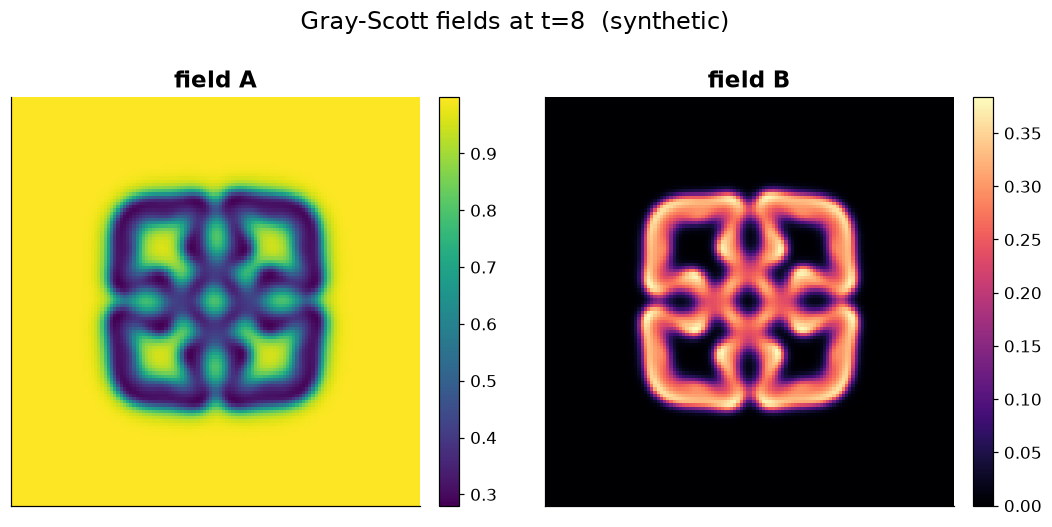

In [3]:
t_snap = fields.shape[1] // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, name, img in zip(axes, ps.FIELD_NAMES, (A[t_snap], B[t_snap])):
    im = ax.imshow(img, cmap=ps.FIELD_CMAPS[name])
    ps.style_field_ax(ax, f"field {name}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Gray-Scott fields at t={bundle.t_index[t_snap]}  ({bundle.source})", y=1.02)
fig.tight_layout()
ps.savefig(fig, "01_field_snapshots")
plt.show()

## 2. Temporal montage

One trajectory through time (top row: A, bottom row: B). The slow drift between
frames is why training spaces frames with `time_stride`.

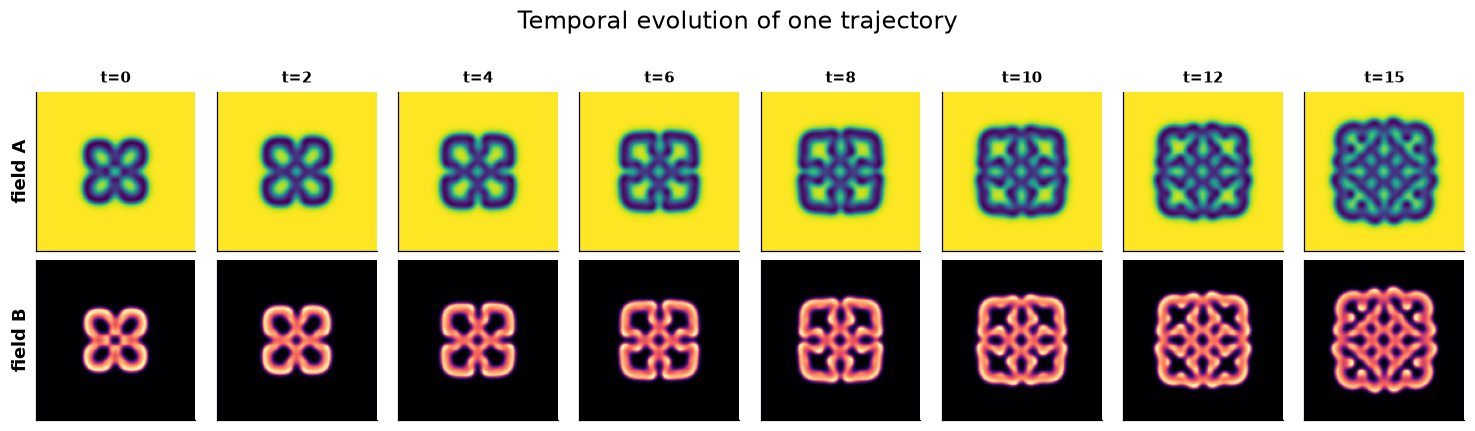

In [4]:
n_cols = min(8, fields.shape[1])
cols = np.linspace(0, fields.shape[1] - 1, n_cols, dtype=int)
fig, axes = plt.subplots(2, n_cols, figsize=(1.7 * n_cols, 4.0))
for j, t in enumerate(cols):
    for i, (name, vol) in enumerate(zip(ps.FIELD_NAMES, (A, B))):
        ax = axes[i][j]
        ax.imshow(vol[t], cmap=ps.FIELD_CMAPS[name])
        ps.style_field_ax(ax)
        if i == 0:
            ax.set_title(f"t={bundle.t_index[t]}", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"field {name}", fontsize=12, fontweight="bold")
fig.suptitle("Temporal evolution of one trajectory", y=1.0)
fig.tight_layout()
ps.savefig(fig, "02_temporal_montage")
plt.show()

## 3. Regime gallery

The `(F, k)` feed/kill parameters produce visually distinct regimes — one per
HDF5 file. We show field **B** (where the structure lives) for several regimes.

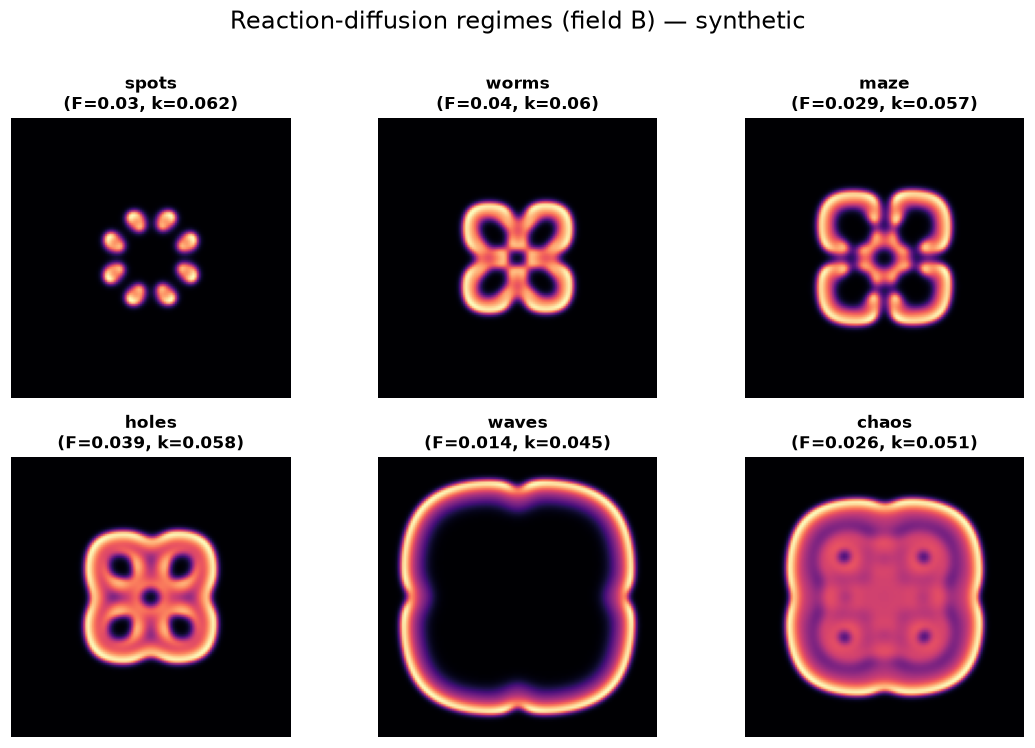

In [5]:
regimes = ps.list_regimes(data_root=DATA_ROOT, split=SPLIT, max_regimes=6)
n = len(regimes)
ncol = min(3, n)
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.4 * nrow), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for k, (label, fld, src) in enumerate(regimes):
    ax = axes[k // ncol][k % ncol]
    ax.imshow(fld[1], cmap=ps.FIELD_CMAPS["B"])
    ax.set_title(label, fontsize=11)
    ps.style_field_ax(ax)
fig.suptitle(f"Reaction-diffusion regimes (field B) — {regimes[0][2]}", y=1.0)
fig.tight_layout()
ps.savefig(fig, "03_regime_gallery")
plt.show()

## 4. Value distributions vs the z-score statistics

Training z-scores each channel with fixed dataset statistics
(`MEAN`/`STD` from `eb_jepa/datasets/gray_scott/dataset.py`). The histograms show
the raw per-channel distributions with those statistics overlaid; B is highly
skewed toward 0 (most of the grid is empty), which is why per-sample VRMSE blows
up and the metric must aggregate numerator/denominator.

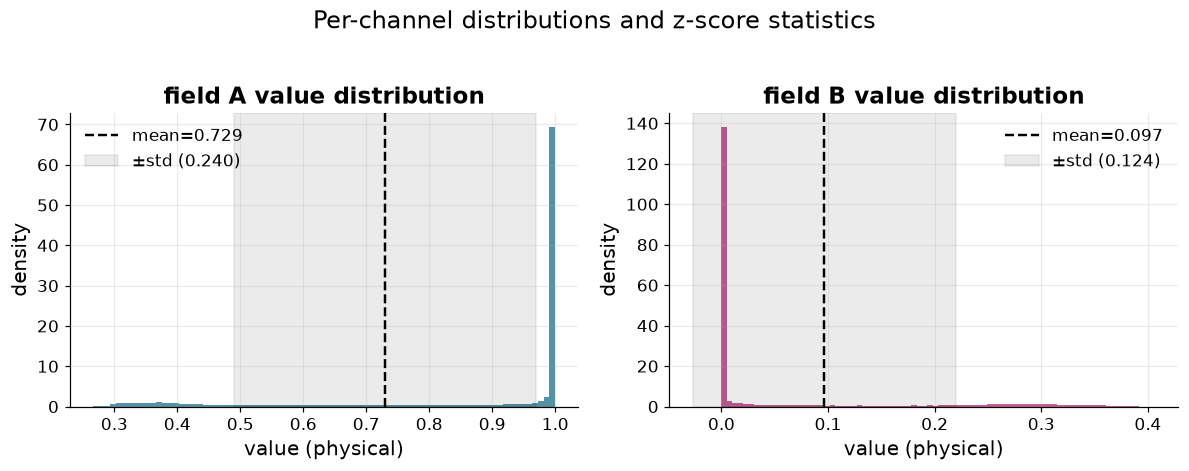

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
colors = {"A": "#2a788e", "B": "#b5367a"}
for ax, name, vol in zip(axes, ps.FIELD_NAMES, (A, B)):
    ci = ps.FIELD_NAMES.index(name)
    ax.hist(vol.ravel(), bins=80, color=colors[name], alpha=0.8, density=True)
    ax.axvline(ps.MEAN[ci], color="k", ls="--", lw=1.6, label=f"mean={ps.MEAN[ci]:.3f}")
    ax.axvspan(ps.MEAN[ci] - ps.STD[ci], ps.MEAN[ci] + ps.STD[ci],
               color="k", alpha=0.08, label=f"±std ({ps.STD[ci]:.3f})")
    ax.set_title(f"field {name} value distribution")
    ax.set_xlabel("value (physical)")
    ax.set_ylabel("density")
    ax.legend()
fig.suptitle("Per-channel distributions and z-score statistics", y=1.02)
fig.tight_layout()
ps.savefig(fig, "04_value_distributions")
plt.show()

## 5. Radial power spectrum

The azimuthally-averaged power spectrum exposes the characteristic length scales
of the patterns — most energy sits at intermediate wavenumbers (the pattern
wavelength), not at the grid scale, which is what a latent predictor must
capture.

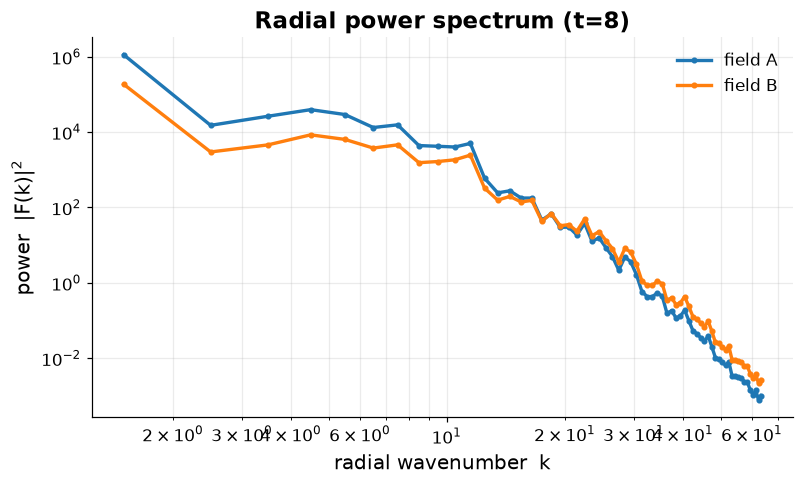

In [7]:
t_spec = fields.shape[1] // 2
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for name, vol in zip(ps.FIELD_NAMES, (A, B)):
    k, power = ps.radial_power_spectrum(vol[t_spec])
    ax.loglog(k[1:], power[1:], marker="o", ms=3, label=f"field {name}")
ax.set_xlabel("radial wavenumber  k")
ax.set_ylabel("power  |F(k)|$^2$")
ax.set_title(f"Radial power spectrum (t={bundle.t_index[t_spec]})")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
ps.savefig(fig, "05_power_spectrum")
plt.show()

## 6. Temporal change-rate — why `time_stride`?

Mean absolute frame-to-frame change for several strides. Gray-Scott evolves
slowly, so consecutive raw frames are nearly identical; striding makes the
dynamics visible (and the prediction task non-trivial).

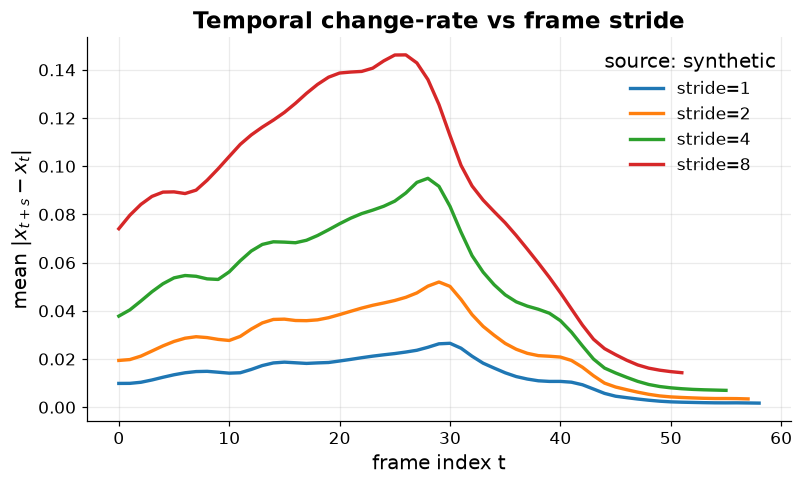

In [8]:
# Load a longer contiguous run (stride 1) to measure change-rate vs stride.
long_bundle = ps.load_demo_trajectory(
    data_root=DATA_ROOT, split=SPLIT, n_frames=60, time_stride=1,
    traj_idx=TRAJ_IDX, t0=T0, prefer="auto",
)
seq = long_bundle.fields            # [2, T, H, W]
strides = [1, 2, 4, 8]
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for s in strides:
    diffs = np.abs(seq[:, s:] - seq[:, :-s]).mean(axis=(0, 2, 3))   # over channels+space
    ax.plot(np.arange(len(diffs)), diffs, label=f"stride={s}")
ax.set_xlabel("frame index t")
ax.set_ylabel(r"mean $|x_{t+s}-x_t|$")
ax.set_title("Temporal change-rate vs frame stride")
ax.legend(title=f"source: {long_bundle.source}")
fig.tight_layout()
ps.savefig(fig, "06_change_rate")
plt.show()

## 7. Animated trajectory (GIF)

A short animation of field B, written to `out/07_trajectory.gif` and embedded.

wrote /home/sardi/eb_jepa_bellwethers/figures/out/07_trajectory.gif


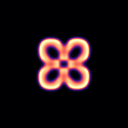

In [10]:
import matplotlib
import imageio.v2 as imageio
from IPython.display import Image as IPyImage, display

cmap = matplotlib.colormaps[ps.FIELD_CMAPS["B"]]
seq_b = long_bundle.fields[1]                         # [T, H, W]
vmin, vmax = np.percentile(seq_b, [1, 99])
norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
frames = [(cmap(norm(f))[..., :3] * 255).astype(np.uint8) for f in seq_b]

ps.OUT_DIR.mkdir(parents=True, exist_ok=True)
gif_path = ps.OUT_DIR / "07_trajectory.gif"
imageio.mimsave(gif_path, frames, fps=10, loop=0)
print("wrote", gif_path)
display(IPyImage(filename=str(gif_path)))